# PMR3404 - Controle I - Versão 2026
# Laboratório 1: Python control system toolbox, controladores PID

# Identificação

**Aluno1 : Augusto Campos**                    **NUSP: 13684662**

**Aluno2 :Matheus Alexandrino Brito**           **NUSP:11261419**

**Turma de Laboratório: B**

**Professor:Newtom**


Nessa primeira aula prática vamos introduzir a utilização do pacote Python control system toolbox para o projeto de sistemas de controle em malha fechada utilizando controladores PID.
As técnicas de projeto de sistemas de controle utilizando os requisitos de desempenho será o tema da Laboratório 2.

Os seguintes temas serão abordados:
- Modelagem de um sistema de controle de posicionamento de antena parabólica,
- Obtenção das funções de transferência de velocidade e de posição do sistema,
- Experimentos com controladores P, PI, PD serão realizados visando principalmente observar o efeito de cada componente: P, I e D.
- Para cada tipo de controlador (i.e. P, PI, PD) analisa-se o efeito da variação dos parâmetros do controlador sobre o controle de velocidade e/ou posição.
- Os scripts necessários são disponibilizados em 4 células de código.
- **Muito embora o questionário seja bastante longo as respostas são triviais dado os scripts fornecidos.**

## Instruções para edição das células de resposta

1. O manual do jupyter notebook pode ser encontrado em https://jupyter-notebook.readthedocs.io/en/stable/notebook.html

2. As células do jupyter podem conter código ou texto que utiliza uma linguagem de formatação denominada Markdown.
   O manual do markdown é encontrado em https://jupyter-notebook.readthedocs.io/en/latest/examples/Notebook/Working%20With%20Markdown%20Cells.html
   
3. Se clicarmos o botão <RUN> numa célula de texto o jupyter realiza a formatação desse texto.
   Se a célula estiver no modo formatado e clicarmos novamente, entra-se no modo de edição do texto.
   
3. As imagens de figuras podem ser inseridas no markdown através de duas maneiras:
- Fazendo referência a um arquivo de um folder. As figuras utilizadas no texto estão dentro do folder ./Figuras
- Fazendo **copy and paste** de uma imagem para uma região desejada da célula de texto. Dessa forma a imagem da figura ficaincorporado no arquivo .ipynb. Recomenda-se esse método para a incorporação de imagens geradas pelo matplotlib. Ao final deve ser verificado se todas as figuras estão incorporadas corretamente. O sistema eventualmente utiliza o mesmo label para se referir a cada imagem e isso pode gerar conflito.
    
4. Os símbolos matemáticos e equações utilizam a sintaxe da linguagem de formatação LaTeX.

5. **Nos scripts o array t que define o vetor de tempo para a simulação e geração dos plots deve ser adaptado para cada caso.**
    
6. **Em algumas situações a estimação da grandeza $\max v_p(t)$ pode gerar erro. Nesse caso não é necessário fazer essa estimativa.**

## Instruções para submissão do relatório

1. Todo relatório deve ser submetido no sistema Moodle de acordo o deadline estabelecido.
2. Submeta um arquivo compactado contendo o arquivo principal do jupyter notebook (.ipynb) e o folder ./Figuras mesmo que não tenho colocado imagens adicionais.
3. **Também no arquivo compactado acrescente uma versão no formato HTML do arquivo jupyter notebook. No menu acesse "File->Save and Export Notebook as ...". O arquivo será utilizado para avaliação do relatório, caso haja dúvidas sobre os resultados o arquivo .ipynb será verificado.**
4. **Nos arquivos .ipynb e .html você deve manter as células que contêm as saídas das execuções dos scripts em Python com as últimas respostas obtidas. Seções que não apresentarem indícios que os scripts foram executados não serão consideradas para nota.**

# 1. Introdução

## 1.1 A Filosofia de projeto de sistemas de controle

Dado um sistema dinâmico (Planta) que não atinge os requisitos de desempenho impostos dentro do contexto
de um determinado projeto, a ideia fundamental de sistemas de controle consiste em projetar um outro
sistema (Controlador) que ao interagir com a planta permite que os requisitos de desempenho 
possam ser atingidos. A principal topologia utilizada para os sistemas de controle em malha fechada
é apresentada na Figura 1.

<img src="./Figuras/standardblock.png" width="50%" height="50%"/>

**Figura 1**

Os requisitos de desempenho se referem ao regime estático e transitório quando o sistema é excitado por sinais
de referência padrão (degrau, rampa, etc.). Como na prática várias situações adversas podem ocorrer
o projeto do sistema de controle deve atender também a requisitos de robustez de desempenho, i.e.,
manter o desempenho mesmo em situações como: incerteza dos parâmetros da planta, variação dos parâmetros da planta, sinais de distúrbios na entrada da planta, ruídos de medida dos sensores, etc.

Os sistemas são descritos por equações diferenciais (domínio do tempo) que tem as funções de transferência como
seus equivalentes no domínio da frequência.

Uma interpretação possível dentro do contexto da teoria de sistemas é que o comportamento do sistema
depende única e exclusivamente da posição dos pólos e zeros de sua função de transferência.
**O projeto de um controlador portanto pode ser entendido como o posicionamento adequado dos pólos e zeros
do sistema no plano complexo $s$**.

**Um dos aspectos principais do projeto de sistemas de controle é que o desempenho que pode ser alcançado
está limitado pelas características da malha aberta $G(s)H(s)$.  Dada uma planta $G(s)$ e escolhido um tipo de
controlador $H(s)$ não é possível alocar os pólos de malha fechada arbitrariamente.**

## 1.2 Definição do sistema de controle em estudo

Um sistema de posicionamento de azimute (movimento lateral) de uma antena
parabólica está representado na Figura 2.
O Diagrama esquemático detalhado do sistema está representado na Figura 3.

<img src="./Figuras/sistema.png" width="40%" height="40%"/>

**Figura 2**
 
<img src="./Figuras/esquematico.jpg" width="50%" height="50%"/>

**Figura 3**
 
Os seguintes parâmetros são definidos:

|Grandeza                              |Símbolo|Valor|Unidade    |
|:-------------------------------------|:------|:----|:----------|
|Tensão de alimentação do potenciômetro|$V$    |10   |volts      |   
|Número de voltas do potenciômetro     |$n$    |1    |           |
|Parâmetro do amplificador de potência |$K_1$  |150  |           | 
|Pólo do amplificador de potência      |$a$    |150  |           |
|Resistência de armadura               |$R_a$  |5    |ohms       |
|Momento de inércia de armadura        |$J_a$  |0.05 |$Kg.m^2$   |
|Atrito viscoso de armadura            |$D_a$  |0.01 |$$N.m.s/rad$$|
|Constante da força contra-eletromotriz|$K_b$  |1    |$V.s/rad$  |
|Constante de torque                   |$K_t$  |1    |$N.m/A$    |
|Número de dentes da engrenagem 1      |$N_1$  |50   |           | 
|Número de dentes da engrenagem 2      |$N_2$  |250  |           |
|Número de dentes da engrenagem 3      |$N_3$  |250  |           |
|Momento de inércia da carga           |$J_L$  |5    |$Kg.m^2$   |
|Atrito viscoso da carga               |$D_L$  |3    |$N.m.s/rad$|

O diagrama de blocos resultante é ilustrado na Figura 4.

<img src="./Figuras/diagblocopos.png" width="80%" height="80%"/>

**Figura 4**

Utilizando os parâmetros definidos na tabela acima
podemos obter os parâmetros que definem as funções de transferência
da Figura 4.

|Parâmetro|Valor|
|:-|:-|
|$K_{pot}$|0.318|
|$K_1$|150|
|$a$|150|
|$K_m$|0.8|
|$a_m$|1.32|
|$K_g$|0.2|

O ganho do pré-amplificador $K$ pode ser interpretado como um controlador proporcional.

Partindo desse diagrama de blocos que define o sistema de controle de posição angular é possível 
facilmente deduzir um possível sistema de controle de velocidade angular como observado na Figura 5. A função de transferência do motor e carga deve ser diferenciado
obtendo-se:
\begin{equation}
\frac{\Omega_m(s)}{E_a(s)} = \frac{K_1}{s+a_m}.
\end{equation}
Adicionalmente deve ser utilizado um tacômetro como sensor de velocidade e que tem como
constante $K_{tac}$.

<img src="./Figuras/diagblocovel.png" width="80%" height="80%"/>

**Figura 5**

A conversão do valor de velocidade angular de entrada $\omega_i$ é convertido para um valor de 
tensão em volts através de um potenciômetro.
**Vamos considerar hipoteticamente que as constantes do potenciômetro e do tacômetro
sejam numericamente equivalentes, i.e.,**
\begin{equation}
K_{pot2} = K_{tac}=0.48.
\end{equation} 

# 2. Funções de transferência

Para a realização de projeto e análise de sistemas de controle em malha fechada é necessário
a redução do diagrama de blocos de um sistema qualquer para a topologia ilustrada na
Figura 1.
 
Os dois blocos que permanecem são o controlador $H(s)$ e a planta $G(s)$.
A função de transferência do sistema de controle em malha fechada pode ser escrita como:
\begin{equation}
\frac{Y(s)}{R(s)} = \frac{G(s)H(s)}{1+G(s)H(s)}.
\end{equation}

Uma outra topologia importante é denominada malha aberta (Veja Figura 6) cuja função de transferência é dada por:
\begin{equation}
\frac{Y(s)}{E(s)} = G(s)H(s).
\end{equation}

<img src="./Figuras/standardopenloop.png" width="40%" height="40%"/>

**Figura 6**

Geralmente é necessário também analisar a planta isoladamente (Ilustrada na Figura 7).
A função de transferência pode ser escrita como:
\begin{equation}
\frac{Y(s)}{U(s)} = G(s).
\end{equation}
 
<img src="./Figuras/standardplant.png" width="30%" height="30%"/> 

**Figura 7**

## 2.1 Sistema de controle de velocidade

Partindo do diagrama de blocos do sistema de controle de velocidade (Figura 5) é possível atingir a topologia do sistema de controle em malha fechada standard
(Figura 1) através da manipulação do diagrama de blocos.

Por exemplo, se admitirmos que $K_{tac}=K_{pot2}$ podemos substituir os dois blocos por um único
bloco colocado após o somador.
É necessário agora estabelecer dois blocos que denominaremos controlador $H_\omega(s)$ e planta $G_\omega(s)$.

O sistema de controle ficará definido como ilustrado na Figura 8:

<img src="./Figuras/diagblocoVelDashed.png" width="80%" height="80%"/>

**Figura 8**

O controlador será definido através da seguinte forma geral:
\begin{equation}
H_\omega(s)=K_{tac}H_1(s).
\end{equation}
Para o nosso propósito $H_1(s)$ pode ser uma constante $K$ como ilustrado na Figura 8 mas estamos interessados em controladores mais complexos do tipo PID.

A planta pode ser escrita como:
\begin{equation}
\frac{\Omega_o(s)}{V_p(s)}=G_\omega(s)=\frac{K_1 K_m K_g}{(s+a)(s+a_m)}
\end{equation}

## Função de transferência de velocidade

**Utilizar o script abaixo**

1. Calcule a função de transferência do sistema com valores numéricos:
$$
G_\omega(s)=\frac{\Omega(s)}{V_p(s)} = \frac{K_c}{s^2+c_1s+c_2} = \frac{24}{s^2+151.3s+198}
$$        
        
2. Reescreva a função de transferência evidenciando os pólos:
$$
G_\omega(s)=\frac{\Omega(s)}{V_p(s)} = \frac{K_d}{(s+d_1)(s+d_2)} = \frac{24}{(s+150)(s+1.32)}
$$

3. Reescreva a função de transferência evidenciando as constantes de tempo:
$$
G_\omega(s)=\frac{\Omega(s)}{V_p(s)}= \frac{K_T}{(T_1s+1)(T_2s+1)}= \frac{0.12}{(\frac{1}{150}s+1)(\frac{1}{1.32}s+1)}
$$

4. Reescreva a função de transferência através da expansão em frações parciais:
$$
G_\omega(s)=\frac{\Omega(s)}{V_p(s)}= \frac{A_1}{(s+d_1)} + \frac{A_2}{(s+d_2)}= \frac{-0.1614}{(s+150)} + \frac{0.1614}{(s+1.32)}
$$

5. Identifique os pólos do sistema $G_\omega(s)$:

|pólo 1|pólo 2|
|:-|:-|
|-1.32|-150|
 
6. Insira abaixo o gráfico da resposta a degrau do sistema:

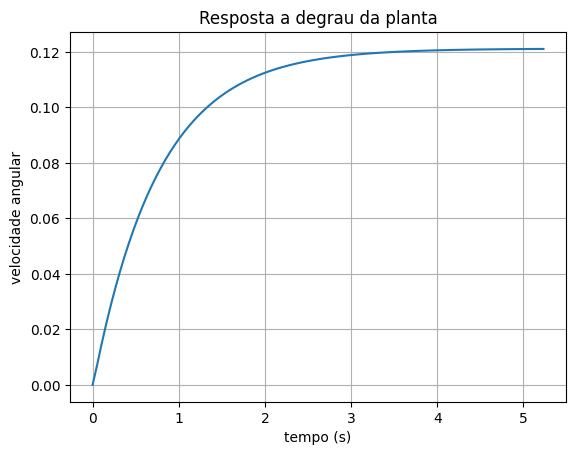
 


-------------
POLOS DA FUNCAO DE TRANSFERENCIA
[-150.  +0.j   -1.32+0.j]
-------------
FT DA PLANTA Gomega(s) = 
<TransferFunction>: sys[6]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          24
  -------------------
  s^2 + 151.3 s + 198
-------------
EXPANSAO EM FRACOES PARCIAIS
R = [ 0.1614205 -0.1614205]
P = [  -1.32 -150.  ]
K = []
-------------
CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA
tempo de subida tr =  1.69 seg
tempo de acomodacao ts =  3.01 seg
maximo sobresinal Mp =  0.0
valor de pico omegaomax =  0.12
instante de pico tp =  5.23 seg
valor de regime estacionario omegaoss =  0.12


c:\Users\nigtt\AppData\Local\Programs\Python\Python312\Lib\site-packages\control\pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


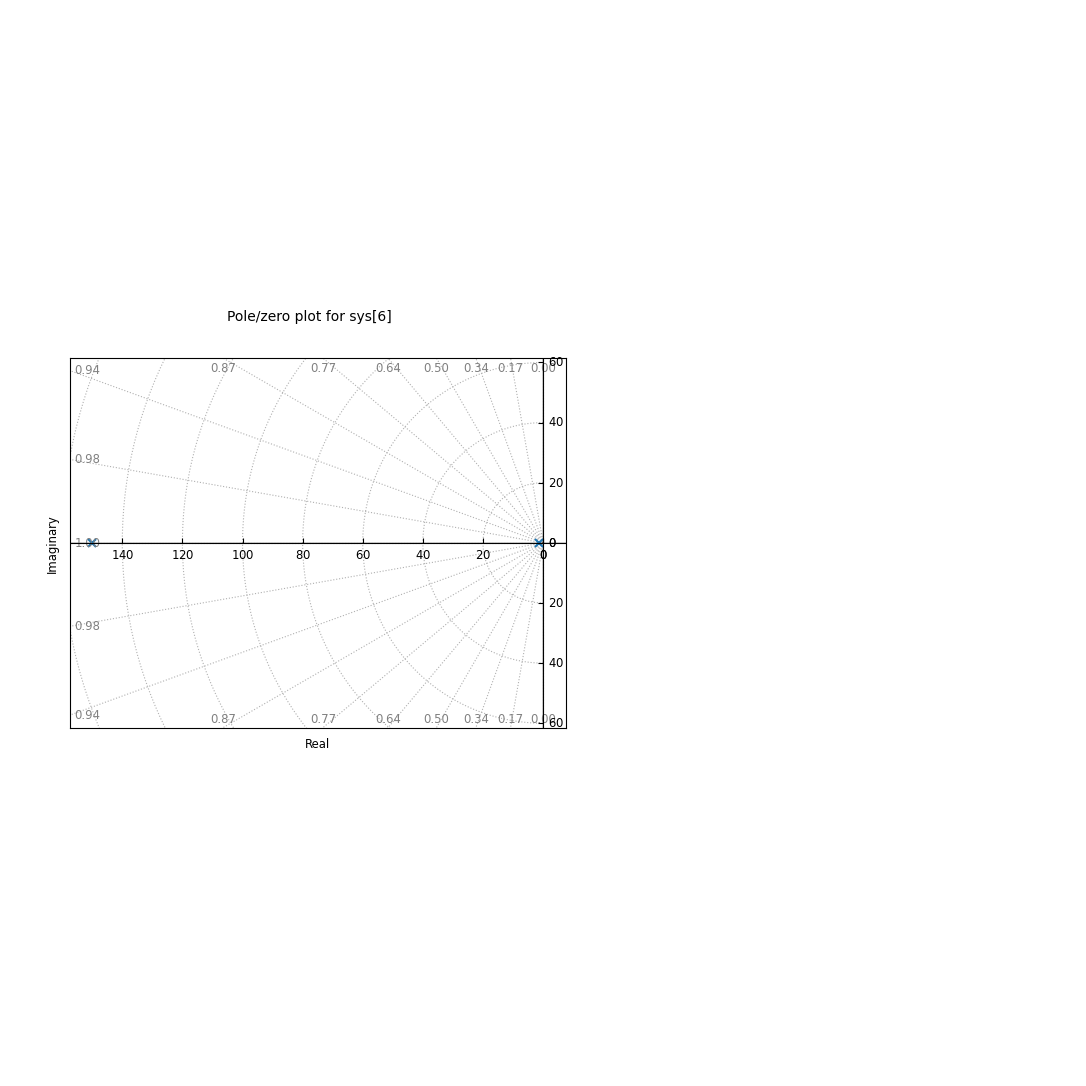

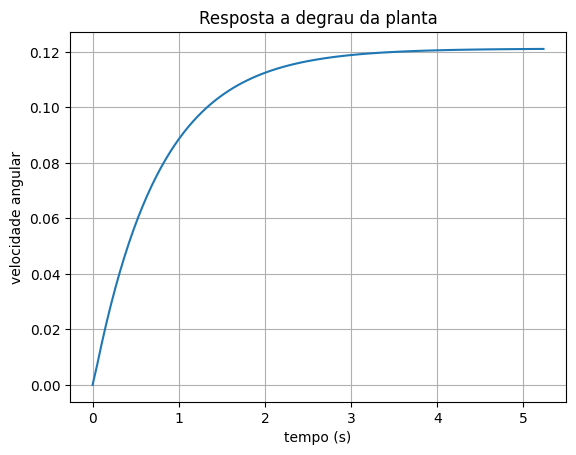

In [1]:
import numpy as np
import scipy as sc
import control as co_general
import matplotlib.pyplot as plt
import control.matlab as co

# Fecha todas as janelas
plt.close('all')
# Parametros da funcao de transferencia
K1 = 150;
Km = 0.8;
Kg = 0.2;
a  = 150;
am = 1.32;
#
# Funcao de transferencia da velocidade angular do sistema
s = co.tf('s');
Gomega = (K1*Km*Kg)/((s+a)*(s+am))
#
# Calculo dos polos da funcao de transferencia Gm
print('-------------')
print('POLOS DA FUNCAO DE TRANSFERENCIA')
print(co.pole(Gomega))
print('-------------')
print('FT DA PLANTA Gomega(s) = ')
print(Gomega)

#
# Expansao em fracoes parciais
# caso nao haja multiplos polos:
#       B(s)       R(1)       R(2)             R(n)
#       ----  =  -------- + -------- + ... + -------- + K(s)
#       A(s)     s - P(1)   s - P(2)         s - P(n)
#
print('-------------')
print('EXPANSAO EM FRACOES PARCIAIS')
B = K1*Km*Kg;
A = [1, a+am, a*am];
[R,P,K]=sc.signal.residue(B,A)
print('R =',R)
print('P =',P)
print('K =',K)
# Plot dos polos e zeros PZMAP
co.pzmap(Gomega,grid=True)
# Resposta Transitoria
S=co.stepinfo(Gomega)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA')
print('tempo de subida tr = ','%.2f' % S['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S['Overshoot'])
print('valor de pico omegaomax = ','%.2f' % S['Peak'])
print('instante de pico tp = ','%.2f' % S['PeakTime'],'seg')
print('valor de regime estacionario omegaoss = ','%.2f' % S['SteadyStateValue'])
# Resposta a degrau da planta
plt.figure(2)
omegao, t = co.step(Gomega)
plt.plot(t,omegao)
plt.title('Resposta a degrau da planta')
plt.xlabel('tempo (s)')
plt.ylabel('velocidade angular')
plt.grid()

# 2.2 Sistema de controle de posição angular

Da mesma forma, é possível partir do diagrama de blocos do sistema de controle de posição (Figura 4) e atingir a topologia do sistema de controle em malha fechada standard
(Figura 1) através da manipulação do diagrama de blocos.

É necessário agora estabelecer dois blocos que denominaremos controlador $H_\theta(s)$ e planta $G_\theta(s)$.

O sistema de controle ficará definido como ilustrado na Figura 9:

<img src="./Figuras/diagblocoPosicaoDashed.png" width="80%" height="80%"/>

**Figura 9**

O controlador será definido através da seguinte forma geral:
\begin{equation}
H_\theta(s)=K_{pot}H_1(s).
\end{equation}
Para o nosso propósito $H_1(s)$ será representado por controladores c PID.

A planta pode ser escrita como:
\begin{equation}
\frac{\Theta_o(s)}{V_p(s)}=G_\theta(s)=\frac{K_1 K_m K_g}{s(s+a)(s+a_m)}
\end{equation}

## Função de transferência de posição

**Utilizar o script abaixo**
    
1. Calcule a função de transferência do sistema com valores numéricos:

$$
G_\theta(s)=\frac{\Theta(s)}{V_p(s)} = \frac{K_c}{s^3+c_1s^2+c_2s+c_3}= \frac{24}{s^3+151.3s^2+198s+0}
$$

2. Reescreva a função de transferência evidenciando os pólos:
$$
G_\theta(s)=\frac{\Theta(s)}{V_p(s)}= \frac{K_d}{s(s+d_1)(s+d_2)}= \frac{24}{s(s+150)(s+1.32)}
$$
		
3. Identifique os pólos do sistema $G_\theta(s)$:
 
|pólo 1|pólo 2|pólo 3|
|:-|:-|:-|
|-150|-1.32|0|
	
4. Insira abaixo o gráfico da resposta a degrau do sistema:
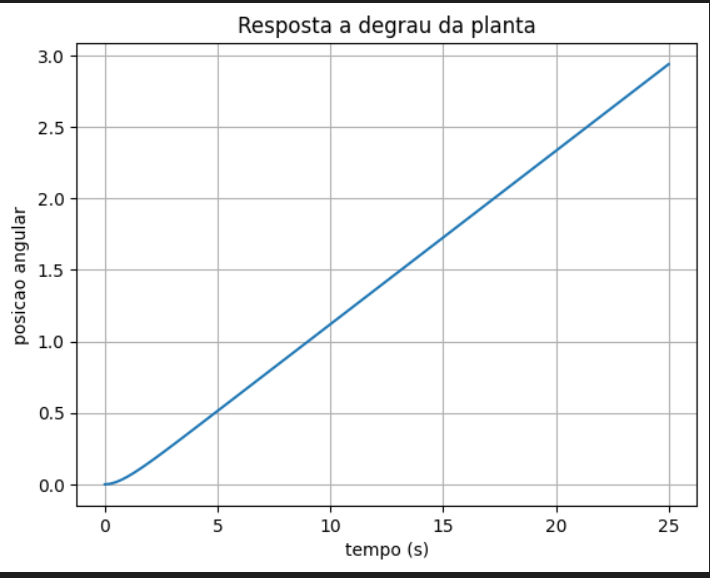


-------------
POLOS DA FUNCAO DE TRANSFERENCIA
[-150.  +0.j   -1.32+0.j    0.  +0.j]
-------------
FT DA PLANTA Gtheta(s) = 
<TransferFunction>: sys[18]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

            24
  -----------------------
  s^3 + 151.3 s^2 + 198 s
-------------
EXPANSAO EM FRACOES PARCIAIS
R = [ 0.12121212 -0.12228826  0.00107614]
P = [   0.     -1.32 -150.  ]
K = []
-------------
CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA
tempo de subida tr =  nan seg
tempo de acomodacao ts =  nan seg
maximo sobresinal Mp =  nan
valor de pico thetaomax =  inf
instante de pico tp =  inf seg
valor de regime estacionario thetaoss =  nan


c:\Users\nigtt\AppData\Local\Programs\Python\Python312\Lib\site-packages\control\pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


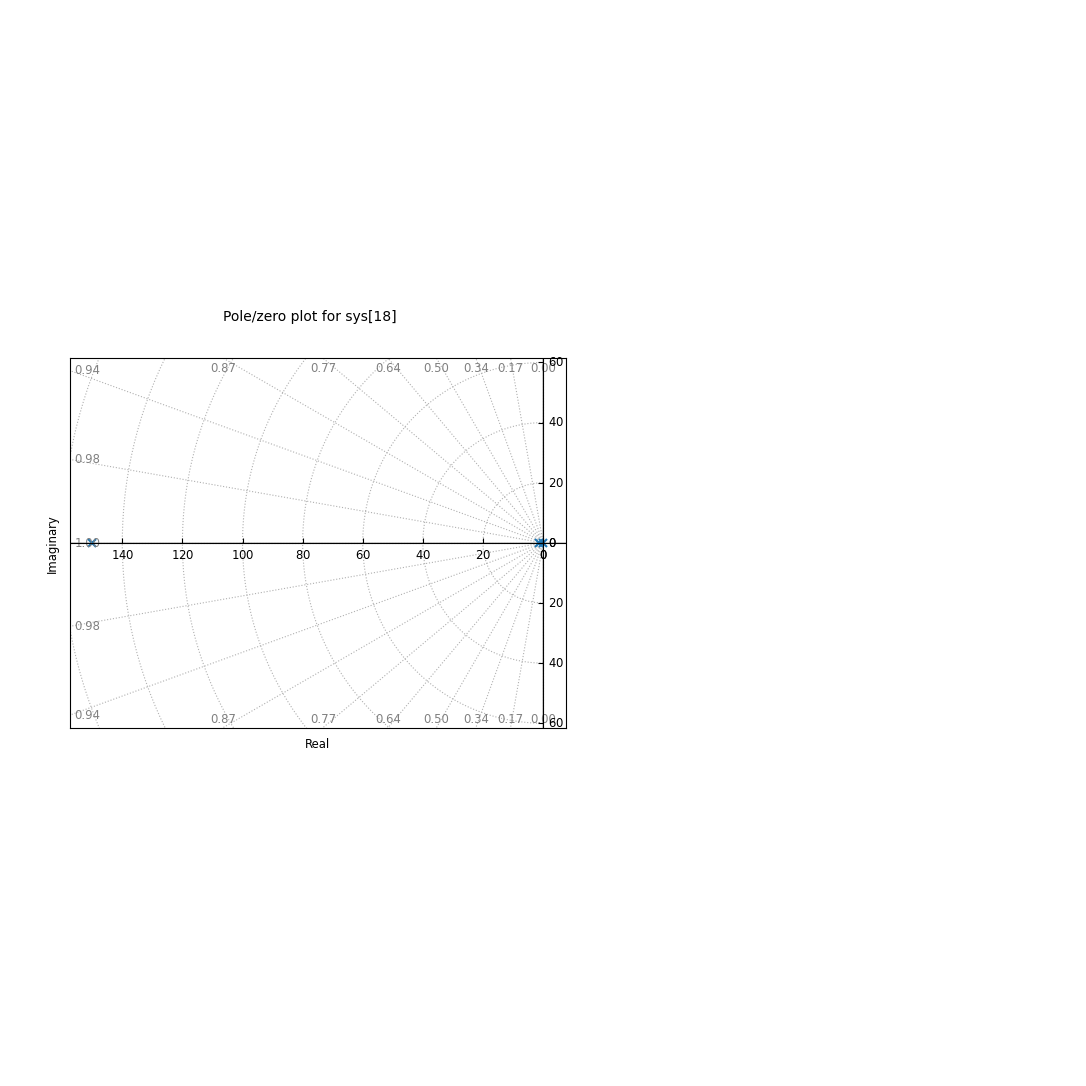

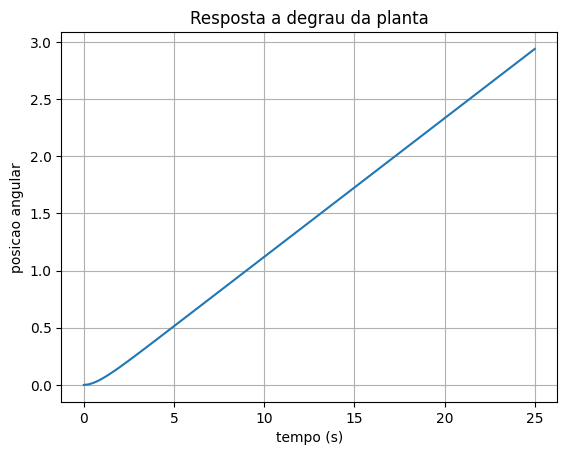

In [2]:
import numpy as np
import scipy as sc
import control as co_general
import matplotlib.pyplot as plt
import control.matlab as co
# Fecha todas as janelas
plt.close('all')
# Parametros da funcao de transferencia
K1 = 150;
Km = 0.8;
Kg = 0.2;
a  = 150;
am = 1.32;
#
# Funcao de transferencia da posicao angular do sistema
s = co.tf('s');
Gtheta = (K1*Km*Kg)/(s*(s+a)*(s+am))
#
# Calculo dos polos da funcao de transferencia Gm
print('-------------')
print('POLOS DA FUNCAO DE TRANSFERENCIA')
print(co.pole(Gtheta))
print('-------------')
print('FT DA PLANTA Gtheta(s) = ')
print(Gtheta)

#
# Expansao em fracoes parciais
# caso nao haja multiplos polos:
#       B(s)       R(1)       R(2)             R(n)
#       ----  =  -------- + -------- + ... + -------- + K(s)
#       A(s)     s - P(1)   s - P(2)         s - P(n)
#
print('-------------')
print('EXPANSAO EM FRACOES PARCIAIS')
B = K1*Km*Kg;
A = [1, a+am, a*am, 0];
[R,P,K]=sc.signal.residue(B,A)
print('R =',R)
print('P =',P)
print('K =',K)
# Plot dos polos e zeros PZMAP
co.pzmap(Gtheta,grid=True)
# Resposta Transitoria
S=co.stepinfo(Gtheta)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA')
print('tempo de subida tr = ','%.2f' % S['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S['Overshoot'])
print('valor de pico thetaomax = ','%.2f' % S['Peak'])
print('instante de pico tp = ','%.2f' % S['PeakTime'],'seg')
print('valor de regime estacionario thetaoss = ','%.2f' % S['SteadyStateValue'])
# Resposta a degrau da planta
plt.figure(2)
thetao, t = co.step(Gtheta)
plt.plot(t,thetao)
plt.title('Resposta a degrau da planta')
plt.xlabel('tempo (s)')
plt.ylabel('posicao angular')
plt.grid()

# 3. Controladores PID

O controlador PID pode ser escrito de diversas formas. Aqui vamos adotar o seguinte formato:
\begin{equation}
H_1(s) = K_p\left( 1 + \frac{1}{T_is}+T_d\frac{s}{\frac{T_d}{N}s+1} \right),
\end{equation}
onde $K_p$ é denominada constante proporcional, $T_i$ é o tempo integral, $T_d$ é o tempo derivativo e
$N$ é o parâmetro do filtro de 1a. ordem que possui um pólo em $s=-N/T_d$.
O filtro é necessário para garantir estabilidade da parte derivativa.

O seu uso prático não necessariamente utiliza os três termos simultaneamente, dessa forma  podemos
observar a utilização de variações como controladores P, PI, PD e PID.

O sucesso industrial dos controladores PID se explica pelo fato de possuir flexibilidade suficiente para
obter uma solução de controle para quase qualquer processo industrial.

Para demonstrar o papel de cada parâmetro do controlador PID realizaremos experimentos de simulação
dos sistemas de controle de velocidade e de posição.

## 3.1 Controlador Proporcional

O controlador proporcional é o controlador mais simples possível e é definido aqui como
$H_1(s)=K_p$.

Algumas características dessa ação de controle:
- O ganho proporcional $K_p$ multiplica o sinal de controle proporcionalmente ao erro,
- Com o aumento do ganho proporcional o sistema reage mais rápido porém pode eventualmente levar  a um sistema mais oscilatório, com maior sobressinal,
- Eventualmente o aumento do ganho proporcional leva o sistema para uma região instável.
- Ganhos proporcionais elevados reduzem a faixa linear de operação dos atuadores devido ao fenômeno de saturação.

**A seguir algumas características desse controlador poderão ser observadas através de
simulações do sistema de controle de velocidade e de posição**

## a. Controle de velocidade: controlador proporcional

**Utilize o script abaixo**

1. Considerando que $H_\omega(s)=K_{tac}K_p$ e que: $$G_{\omega}(s) = \frac{K_1 K_m K_g}{(s+a)(s+a_m)},$$ calcule o erro estático $\omega_{e_{ss}}$ do sistema de controle em malha fechada (Veja Figura  8) para uma entrada degrau $\Omega_i(s)=A/s$. Utilize os seguintes resultados (As variáveis aqui se referem à Figura 1):
    \begin{equation} e_{ss} = \lim_{t\rightarrow\infty}e(t) = \lim_{s\rightarrow 0} s E(s),\end{equation}
	\begin{equation}\frac{E(s)}{R(s)}=\frac{1}{1+GH(s)}.\end{equation}
    
$$
\begin{aligned}
E(s) &= R(s) - Y(s) \\
Y(s) &= \frac{GH}{1 + GH} R(s) \\
E(s) &= \frac{1}{1 + GH} R(s) \\
R(s) &= \frac{A}{s} \\
e_{ss} &= \lim_{t \to \infty} e(t) = \lim_{s \to 0} sE(s) \\
&= \lim_{s \to 0} s \cdot \frac{1}{1 + GH(s)} \cdot \frac{1}{s} \\
&= \frac{1}{1 + G(0)H(0)} \\
G_{\omega}(0) &= \frac{24}{150 \cdot 1.32} = 0.121212\ldots \\
H_{\omega}(0) &= K_{tac} K_p = 0.48 K_p \\
e_{ss} &= \frac{1}{1 + 0.121212 \cdot 0.48 K_p} \\
&= \frac{1}{1 + 0.0581818 K_p}
\end{aligned}
$$

	      
2. Utilizando o script de controle de velocidade realize simulações do sistema de  controle em malha fechada com três valores do ganho proporcional do controlador $K_p=\{ 3.0, 5.0, 7.0 \}$.
          
3. Identifique os pólos da malha aberta $GH_\omega(s)$ para cada um dos valores de $K_p$:

|$$K_p$$|$$K_{p_1}$$|$$K_{p_2}$$|$$K_{p_3}$$|
|:-|:-|:-|:-|
|pólo 1|-150|-150|-150|       
|pólo 2|-1,32|-1,32|-1,32|        	  		  

3. Identifique os pólos da malha fechada para cada um dos valores de $K_p$:

|$$K_p$$|$$K_{p_1}$$|$$K_{p_2}$$|$$K_{p_3}$$|
|:-|:-|:-|:-|
|pólo 1|-149,768|-149,612|-149,456|
|pólo 2|-1,553|-1,708|-1,864|

4. Compare a posição dos pólos de malha fechada em relação à posição dos pólos de malha aberta.

**O polo rápido praticamente não se alterou com o uso do controle proporcional, em malha aberta era de -150 e no kp máximo foi para -149,456, já o polo lento varia bastante, de -1,32 em malha aberta até -1,86 com kp máximo, isso está de acordo com o esperado, já que quanto mais o polo se afasta da origem negativamente, apresentam a constante de tempo menor e resposta mais rápida**
 
5. Preencha na tabela abaixo o  erro estático para cada valor de $K_p$:

|$$K_p$$|$$\omega_{e_{ss}}$$|
|:-|:-|
|$K_{p_1}$|0,8511|
|$K_{p_2}$|0,7750|  
|$K_{p_3}$|0,7102|    		  

6. Insira abaixo o gráfico da resposta transitória para uma entrada do tipo degrau unitário.

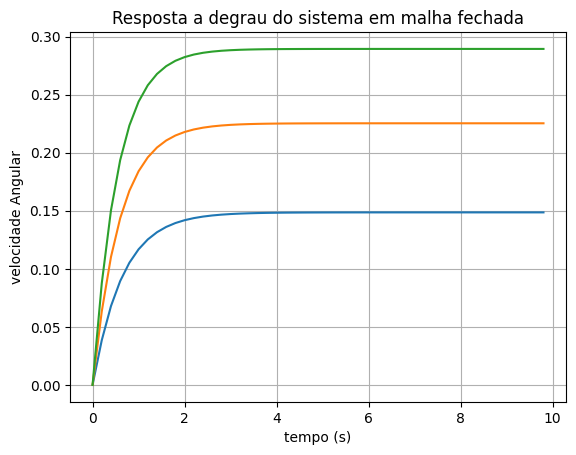

7. Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação $t_s$, Máximo sobresinal $M_p$ da variável $\omega_o(t)$ e $\max v_p(t)$ (Valor máximo da saída do controlador $v_p(t)$)

|$$K_p$$|$$t_r$$|$$t_s$$|$$M_p$$|$$\max v_p(t)$$|
|:-|:-|:-|:-|:-|
|$K_{p_1}$|1,438|2,561|0|1,40|
|$K_{p_2}$|1,307|2,328|0|2,40|
|$K_{p_3}$|1,198|2,133|0|3,36|		  		  

8. Como as grandezas $t_r$, $t_s$, $M_p$ e $\max v_p(t)$ variam com a variação de $K_p$ ?

**O tempo de subida e o tempo de acomodação do sistema aumentam cerca de 17% comparando o kp de 3 com o kp de 7, mas isso teve um custo a tensão máxima necessária para manter a velocidade em regime estacionário aumentou cerca de 95%**


## O script abaixo deve ser utilizado para todos os exercícios relativos a controle de velocidade adaptando o código para cada caso



-------------------------
RELATORIO
Funcao de transferencia do sistema
Gw =  <TransferFunction>: sys[29]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          24
  -------------------
  s^2 + 151.3 s + 198

FUNCAO DE TRANSFERENCIA DE MALHA ABERTA
GHw1 =  <TransferFunction>: sys[31]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         34.56
  -------------------
  s^2 + 151.3 s + 198
GHw2 =  <TransferFunction>: sys[33]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         57.6
  -------------------
  s^2 + 151.3 s + 198
GHw3 =  <TransferFunction>: sys[35]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         80.64
  -------------------
  s^2 + 151.3 s + 198

POLOS E ZEROS DE MALHA ABERTA
-------------
POLOS E ZEROS - GHw1
Polos =  [-150.  +0.j   -1.32+0.j]
Zeros =  []
-------------
POLOS E ZEROS - GHw2
Polos =  [-150.  +0.j   -1.32+0.j]
Zeros =  []
-------------
POLOS E ZEROS - GHw3
Polos =  [-150.  +0.j   -1.32+0.j]
Zeros =  []

FUNCAO DE TRANSFERENCIA DE MALHA FECHADA
GHw1/(1+GHw1) = 

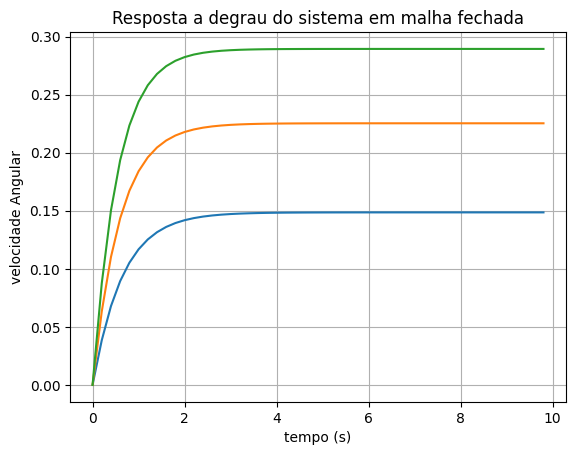

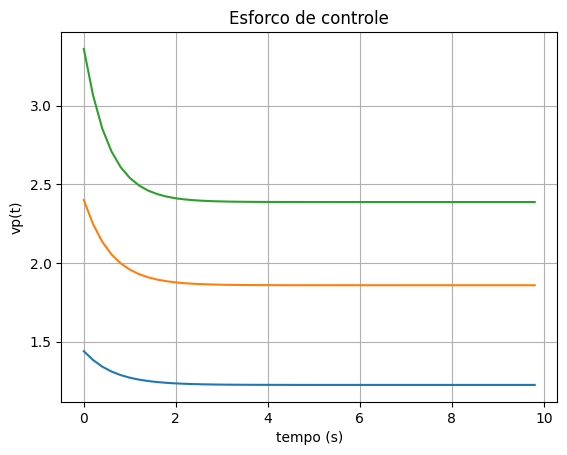

In [3]:
#
# Script para teste de controle de velocidade com controladores PID
#
import numpy as np
import control as co_general
import matplotlib.pyplot as plt
import control.matlab as co
# Fecha todas as janelas
plt.close('all')
# Controle de velocidade angular do motor eletrico CC
# Testes com controle PID
#
# Definicao dos valores dos parametros do sistema
#
# Constante do tacometro
Ktac = 0.48;
# Parametros da funcao de transferencia Gw(s)
K1 = 150;
Km = 0.8;
Kg = 0.2;
a  = 150;
am = 1.32;
#
# Funcao de transferencia da velocidade angular do sistema
s = co.tf('s');
Gw = (K1*Km*Kg)/((s+a)*(s+am))
print('\n\n-------------------------')
print('RELATORIO')
print('Funcao de transferencia do sistema')
print('Gw = ',Gw)
#
# Controlador PID H1(s)
#                      1        Td*s
#   H1(s) = Kp*( 1 + ----- + ------------ )    
#                     Ti*s     (Td/N)*s+1
# 
#   A parte derivativa possui um Filtro de 1a. ordem
#   com polo em s = (-N/Td)
#
# Qto Maior Ti menor o seu efeito 
# Qto maior N menor o efeito do Filtro de 1a. Ordem
#

# Controlador Proporcional
#H1 = Kp
# Controlador PI
#H1 = Kp*(1+ 1/(Ti*s))
# Controlador PD sem filtro
#H1 = Kp*(1+Td*s)
# Controlador PD com filtro
#H1 = Kp*(1+Td*s/(Td*s/N+1))

# Definicao dos controladores
# Escolha dos parametros
#
# Controlador 1
Kp1 = 3.0;
Ti1 = 1;
Td1 = 1;
N1  = 1;
# Escolher um dos controladores
# Controlador Proporcional
H1 = Kp1
# Controlador PI
#H1 = Kp1*(1+ 1/(Ti1*s))
# Controlador PD sem filtro
#H1 = Kp1*(1+Td1*s)
# Controlador PD com filtro
#H1 = Kp1*(1+Td1*s/(Td1*s/N1+1))
Hw1 = Ktac*H1
# Controlador 2
Kp2 = 5.0;
Ti2 = 1;
Td2 = 1;
N2  = 1;
# Escolher um dos controladores
# Controlador Proporcional
H2 = Kp2
# Controlador PI
#H2 = Kp2*(1+ 1/(Ti2*s))
# Controlador PD sem filtro
#H2 = Kp2*(1+Td2*s)
# Controlador PD com filtro
#H2 = Kp2*(1+Td2*s/(Td2*s/N2+1))
Hw2 = Ktac*H2
# Controlador 3
Kp3 = 7.0;
Ti3 = 1;
Td3 = 1;
N3  = 1;
# Escolher um dos controladores
# Controlador Proporcional
H3 = Kp3
# Controlador PI
#H3 = Kp3*(1+ 1/(Ti3*s))
# Controlador PD sem filtro
#H3 = Kp3*(1+Td3*s)
# Controlador PD com filtro
#H3 = Kp3*(1+Td3*s/(Td3*s/N3+1))
Hw3 = Ktac*H3
#
# Definicao da malha aberta
# Sao definidos 3 sistemas distintos
#
GHw1 = Hw1*Gw
GHw2 = Hw2*Gw
GHw3 = Hw3*Gw
print('\nFUNCAO DE TRANSFERENCIA DE MALHA ABERTA')
print('GHw1 = ',GHw1)
print('GHw2 = ',GHw2)
print('GHw3 = ',GHw3)
#
# Polos e zeros de malha aberta
#
print('\nPOLOS E ZEROS DE MALHA ABERTA')
print('-------------')
print('POLOS E ZEROS - GHw1')
print('Polos = ',co.pole(GHw1))
print('Zeros = ',co.zero(GHw1))
print('-------------')
print('POLOS E ZEROS - GHw2')
print('Polos = ',co.pole(GHw2))
print('Zeros = ',co.zero(GHw2))
print('-------------')
print('POLOS E ZEROS - GHw3')
print('Polos = ',co.pole(GHw3))
print('Zeros = ',co.zero(GHw3))
#
# definicao da malha fechada
# realimentacao unitaria
#
# Funcao de transferencia em malha fechada
# pode ser definida em Matlab utilizando-se
# O comando feedback(S1,S2) 
# Onde o sistema S1 se encontra na malha direta
# e S2 se encontra na malha de realimentacao
# No caso desse sistema a malha direta
# e' G(s)H(s) e malha de realimentacao e' 
# unitaria
#
# R(s)  E(s)|------|  |------|  U(s)
#---->(+)---| H(s) |--| G(s) |------->
#    _ ^    |------|  |------|    |
#      |---------------------------                       
#      
cloop1 = co.feedback(GHw1,1)
cloop2 = co.feedback(GHw2,1)
cloop3 = co.feedback(GHw3,1)
print('\nFUNCAO DE TRANSFERENCIA DE MALHA FECHADA')
print('GHw1/(1+GHw1) = ',cloop1)
print('GHw2/(1+GHw2) = ',cloop2)
print('GHw3/(1+GHw3) = ',cloop3)
#
# Polos e zeros de malha fechada
# comando pole() obtem os polos do sistema
# e zero() obtem os zeros do sistema
#
print('\nPOLOS E ZEROS DE MALHA FECHADA')
print('-------------')
print('Polos e zeros cloop1')
print('Polos = ',co.pole(cloop1))
print('Zeros = ',co.zero(cloop1))
print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
print('_____Polos____________zeta_______omegan')
co.damp(cloop1)
print('-------------')
print('Polos e zeros cloop2')
print('Polos = ',co.pole(cloop2))
print('Zeros = ',co.zero(cloop2))
print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
print('_____Polos____________zeta_______omegan')
co.damp(cloop2)
print('-------------')
print('Polos e zeros cloop3')
print('Polos = ',co.pole(cloop3))
print('Zeros = ',co.zero(cloop3))
print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
print('_____Polos____________zeta_______omegan')
co.damp(cloop3)
#
# Grafico da resposta a degrau unitario
#
plt.figure(1)
# Definicao do vetor de tempo t
t=[x*0.2 for x in range(0,50)]
omegao1, t = co.step(cloop1,t)
omegao2, t = co.step(cloop2,t)
omegao3, t = co.step(cloop3,t)
plt.plot(t,omegao1,t,omegao2,t,omegao3)
plt.title('Resposta a degrau do sistema em malha fechada')
plt.xlabel('tempo (s)')
plt.ylabel('velocidade Angular')
plt.grid()
# Calcula as caracteristicas da resposta transitoria
#  stepinfo(sys, T=None, SettlingTimeThreshold=0.02, RiseTimeLimits=(0.1,0.9))
#  S: a dictionary containing:
#        RiseTime: Time from 10% to 90% of the steady-state value.
#        SettlingTime: Time to enter inside a default error of 2%
#        SettlingMin: Minimum value after RiseTime
#        SettlingMax: Maximum value after RiseTime
#        Overshoot: Percentage of the Peak relative to steady value
#        Undershoot: Percentage of undershoot
#        Peak: Absolute peak value
#        PeakTime: time of the Peak
#        SteadyStateValue: Steady-state value
S1 = co.stepinfo(cloop1)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop1')
print('tempo de subida tr = ','%.2f' % S1['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S1['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S1['Overshoot'])
print('valor de pico thetaomax = ','%.2f' % S1['Peak'])
print('instante de pico tp = ','%.2f' % S1['PeakTime'],'seg')
print('valor de regime estacionario omegaoss = ','%.2f' % S1['SteadyStateValue'])
S2 = co.stepinfo(cloop2)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop2')
print('tempo de subida tr = ','%.2f' % S2['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S2['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S2['Overshoot'])
print('valor de pico thetaomax = ','%.2f' % S2['Peak'])
print('instante de pico tp = ','%.2f' % S2['PeakTime'],'seg')
print('valor de regime estacionario omegaoss = ','%.2f' % S2['SteadyStateValue'])
S3 = co.stepinfo(cloop3)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop3')
print('tempo de subida tr = ','%.2f' % S3['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S3['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S3['Overshoot'])
print('valor de pico thetaomax = ','%.2f' % S3['Peak'])
print('instante de pico tp = ','%.2f' % S3['PeakTime'],'seg')
print('valor de regime estacionario omegaoss = ','%.2f' % S3['SteadyStateValue'])
#
# Funcao de transferencia para calculo do esforco de controle u(t)
# o sinal u(t) pode ser calculado definindo-se
# um sistema de controle em malha fechada onde H(s)
# esta na malha direta e G(s) na malha de realimentacao
#
# R(s)  E(s)|------|        U(s)
#---->(+)---| H(s) |------------>
#    _ ^    |------|    |
#      |                |
#      |    |------|    |
#      |----| G(s) |<----
#           |------|
#      
esforco1 = co.feedback(Hw1,Gw)
esforco2 = co.feedback(Hw2,Gw)
esforco3 = co.feedback(Hw3,Gw)
vp1, t = co.step(esforco1,t)
vp2, t = co.step(esforco2,t)
vp3, t = co.step(esforco3,t)
plt.figure(2)
plt.plot(t,vp1,t,vp2,t,vp3)
plt.title('Esforco de controle')
plt.xlabel('tempo (s)')
plt.ylabel('vp(t)')
plt.grid()
#
# Caracteristicas do esforco de controle
#
print('\nESFORCO DE CONTROLE')
SE1 = co.stepinfo(esforco1)
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE cloop1')
print('valor de pico vpmax = ','%.2f' % SE1['Peak'])
print('instante de pico tp = ','%.2f' % SE1['PeakTime'],'seg')
print('valor de regime estacionario vpss = ','%.2f' % SE1['SteadyStateValue'])
SE2 = co.stepinfo(esforco2)
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE cloop2')
print('valor de pico vpmax = ','%.2f' % SE2['Peak'])
print('instante de pico tp = ','%.2f' % SE2['PeakTime'],'seg')
print('valor de regime estacionario vpss = ','%.2f' % SE2['SteadyStateValue'])
SE3 = co.stepinfo(esforco3)
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE cloop3')
print('valor de pico vpmax = ','%.2f' % SE3['Peak'])
print('instante de pico tp = ','%.2f' % SE3['PeakTime'],'seg')
print('valor de regime estacionario vpss = ','%.2f' % SE3['SteadyStateValue'])

## b. Controle de Posição: controlador proporcional

O sistema de controle de posição possui na malha aberta $GH_\theta(s)$  um integrador $1/s$ adicional
e uma constante do potenciômetro $K_{pot}$ da mesma ordem de magnitude de $K_{tac}$.

Será verificado que a introdução do integrador torna o sistema sistema mais lento
o que requer a utilização de um ganho $K_p$ bem maior.
Entretanto o integrador transforma o sistema em um sistema do tipo 1.
Como consequência o erro $\theta_{e_{ss}}$ se torna nulo para um sinal de 
referência do tipo degrau.

1. Considerando que $H_\theta(s)=K_{pot}K_p$ e que: $$G_{\theta}(s) = \frac{K_1 K_m K_g}{s(s+a)(s+a_m)},$$ calcule o erro estático $\theta_{e_{ss}}$ do sistema de controle em malha fechada (Veja Figura 9) para uma entrada degrau $\Theta_i(s)=A/s$.

**[Resposta $\theta_{e_{ss}}$ = 0]**
		
2. Utilizando o script de controle de posição realize simulações do sistema de controle em malha fechada com três valores do ganho proporcional do controlador $K_p=\{1.0, 2.0, 5.0\}$.
		
3. Identifique os pólos da malha aberta $GH_\theta(s)$ para cada um dos valores de $K_p$:
 
|$$K_p$$|$$K_{p_1}$$|$$K_{p_2}$$|$$K_{p_3}$$|
|:-|:-|:-|:-|
|pólo 1| -150| -150| -150|
|pólo 2|-1.35|-1.33|-1.33|
|pólo 3|0.037|0.019|0.013|				  		  
 		
4. Identifique os pólos da malha fechada para cada um dos valores de $K_p$:
 
|$$K_p$$|$$K_{p_1}$$|$$K_{p_2}$$|$$K_{p_3}$$|
|:-|:-|:-|:-|
|pólo 1|  -150|  -150| -150|
|pólo 2| -1.28| -1.24|-1.08|
|pólo 3|-0.038|-0.082|-0.23|				  		  

5. Compare a posição dos pólos de malha fechada em relação à posição dos pólos de malha aberta.

**[Resposta - Os polos em malha aberta não dependem de Kp, enquanto os polos em malha fechada dependem do Kp e por isso podem ser usado para analise do desempenho]**
 
6. Insira abaixo o gráfico da resposta transitória para uma entrada do tipo degrau unitário.

**[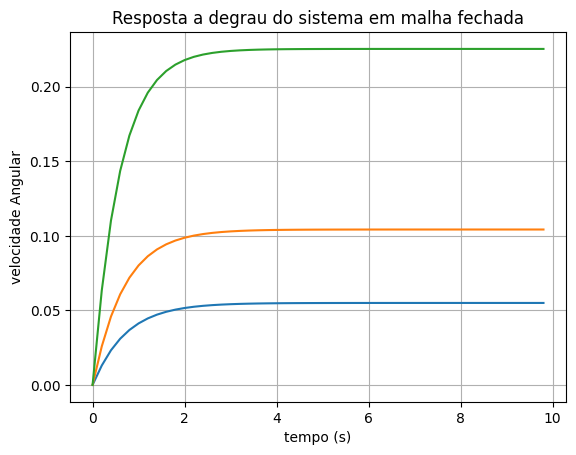]**
 		
7. Preencha na tabela abaixo o  erro estático para cada valor de $K_p$:

|$$K_p$$|$$\theta_{e_{ss}}$$|
|:-|:-|
|$$K_{p_1}$$|0.89|   
|$$K_{p_2}$$|0.80| 	  
|$$K_{p_3}$$|0.62| 		  
 			
8. Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação $t_s$, Máximo sobresinal $M_p$ da variável $\omega_o(t)$ e $\max v_p(t)$ (Valor máximo da saída do controlador $v_p(t)$)
 
|$$K_p$$|$$t_r$$|$$t_s$$|$$M_p$$|$$\max v_p(t)$$|
|:-|:-|:-|:-|:-|
|$$K_{p_1}$$|3.37|13.5|0|2.25|
|$$K_{p_2}$$|2.55|10.2|0|   1|
|$$K_{p_3}$$|1.47|5.88|0| 0.5|
     
9. Como as grandezas $t_r$, $t_s$, $M_p$ e $\max v_p(t)$ variam com a variação de $K_p$ ?

**[Resposta - Quando Kp aumenta tr e ts diminui, mas o Mp pode aumentar, e quando maior for Kp menor sera o MaxVp(t) ]**

## O script abaixo deve ser utilizado para todos os exercícios relativos a controle de posição adaptando o código para cada caso



-------------------------
RELATORIO
Funcao de transferencia do sistema
Gp =  <TransferFunction>: sys[95]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

            24
  -----------------------
  s^3 + 151.3 s^2 + 198 s

FUNCAO DE TRANSFERENCIA DE MALHA ABERTA
GHp1 =  <TransferFunction>: sys[126]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         3.816 s + 38.16
  ------------------------------
  0.1 s^4 + 15.13 s^3 + 19.8 s^2
GHp2 =  <TransferFunction>: sys[127]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         7.632 s + 38.16
  ------------------------------
  0.2 s^4 + 30.26 s^3 + 39.6 s^2
GHp3 =  <TransferFunction>: sys[128]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        19.08 s + 38.16
  ----------------------------
  0.5 s^4 + 75.66 s^3 + 99 s^2

POLOS E ZEROS DE MALHA ABERTA
-------------
POLOS E ZEROS - GHp1
Polos =  [-150.  +0.j   -1.32+0.j    0.  +0.j    0.  +0.j]
Zeros =  [-10.+0.j]
-------------
POLOS E ZEROS - GHp2
Polos =  [-150.  +0.j   -1.32+0.j    0.  +0.j    0

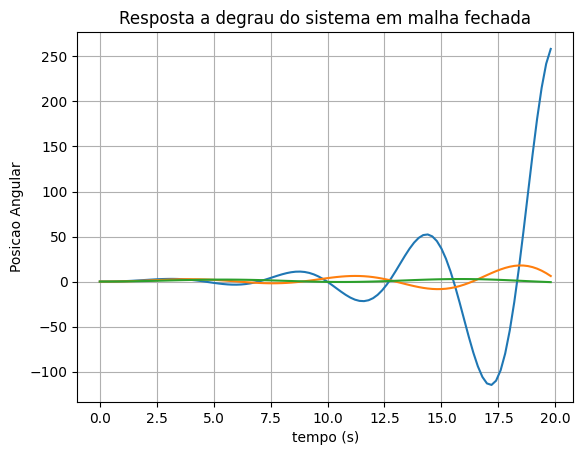

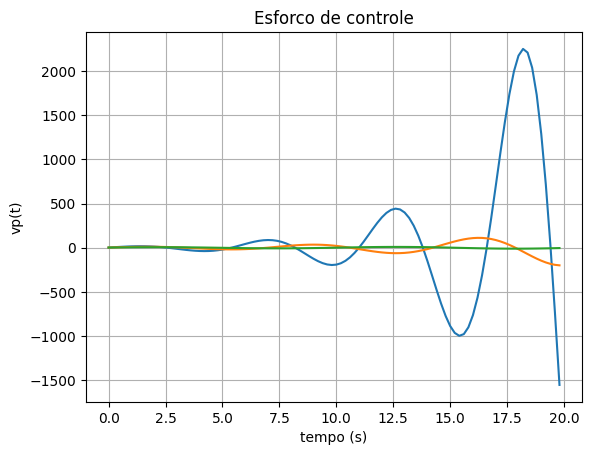

In [ ]:
#
# Script para teste de controle de posicao com controladores PID
#
import numpy as np
import control as co_general
import matplotlib.pyplot as plt
import control.matlab as co
# Fecha todas as janelas
# Nao utilizar em Jupyter Notebook
plt.close('all')
# Controle de posicao angular do motor eletrico CC
# Testes com controle PID
#
# Definicao dos valores dos parametros do sistema
#
# Constante do tacometro
Kpot = 0.318;
# Parametros da funcao de transferencia Gw(s)
K1 = 150;
Km = 0.8;
Kg = 0.2;
a  = 150;
am = 1.32;
#
# Funcao de transferencia da posição angular do sistema
s = co.tf('s');
Gp = (K1*Km*Kg)/(s*(s+a)*(s+am))
print('\n\n-------------------------')
print('RELATORIO')
print('Funcao de transferencia do sistema')
print('Gp = ',Gp)
#
# Controlador PID H1(s)
#                      1        Td*s
#   H1(s) = Kp*( 1 + ----- + ------------ )    
#                     Ti*s     (Td/N)*s+1
# 
#   A parte derivativa possui um Filtro de 1a. ordem
#   com polo em s = (-N/Td)
#
# Qto Maior Ti menor o seu efeito 
# Qto maior N menor o efeito do Filtro de 1a. Ordem
#

# Controlador Proporcional
#H1 = Kp

# Controlador PI
#H1 = Kp*(1+ 1/(Ti*s))

# Controlador PD sem filtro
#H1 = Kp*(1+Td*s)

# Controlador PD com filtro
#H1 = Kp*(1+Td*s/(Td*s/N+1))

# Definicao dos controladores
# Escolha dos parametros
#
# Controlador 1
Kp1 = 5;
Ti1 = 0.1;
Td1 = 1;
N1  = 1;
# Escolher um dos controladores

# Controlador Proporcional
# H1 = Kp1

# Controlador PI
H1 = Kp1*(1+ 1/(Ti1*s))

# Controlador PD sem filtro
#H1 = Kp1*(1+Td1*s)

# Controlador PD com filtro
#H1 = Kp1*(1+Td1*s/(Td1*s/N1+1))
Hp1 = Kpot*H1

# Controlador 2
Kp2 = 5;
Ti2 = 0.2;
Td2 = 1;
N2  = 1;
# Escolher um dos controladores

# Controlador Proporcional
# H2 = Kp2

# Controlador PI
H2 = Kp2*(1+ 1/(Ti2*s))

# Controlador PD sem filtro
#H2 = Kp2*(1+Td2*s)

# Controlador PD com filtro
#H2 = Kp2*(1+Td2*s/(Td2*s/N2+1))
Hp2 = Kpot*H2

# Controlador 3
Kp3 = 5;
Ti3 = 0.5;
Td3 = 1;
N3  = 1;
# Escolher um dos controladores
# Controlador Proporcional
# H3 = Kp3

# Controlador PI
H3 = Kp3*(1+ 1/(Ti3*s))

# Controlador PD sem filtro
#H3 = Kp3*(1+Td3*s)

# Controlador PD com filtro
#H3 = Kp3*(1+Td3*s/(Td3*s/N3+1))
Hp3 = Kpot*H3
#
# Definicao da malha aberta
# Sao definidos 3 sistemas distintos
#
GHp1 = Hp1*Gp
GHp2 = Hp2*Gp
GHp3 = Hp3*Gp
print('\nFUNCAO DE TRANSFERENCIA DE MALHA ABERTA')
print('GHp1 = ',GHp1)
print('GHp2 = ',GHp2)
print('GHp3 = ',GHp3)
#
# Polos e zeros de malha aberta
#
print('\nPOLOS E ZEROS DE MALHA ABERTA')
print('-------------')
print('POLOS E ZEROS - GHp1')
print('Polos = ',co.pole(GHp1))
print('Zeros = ',co.zero(GHp1))
print('-------------')
print('POLOS E ZEROS - GHp2')
print('Polos = ',co.pole(GHp2))
print('Zeros = ',co.zero(GHp2))
print('-------------')
print('POLOS E ZEROS - GHp3')
print('Polos = ',co.pole(GHp3))
print('Zeros = ',co.zero(GHp3))
#
# definicao da malha fechada
# realimentacao unitaria
#
# Funcao de transferencia em malha fechada
# pode ser definida em Matlab utilizando-se
# O comando feedback(S1,S2) 
# Onde o sistema S1 se encontra na malha direta
# e S2 se encontra na malha de realimentacao
# No caso desse sistema a malha direta
# e' G(s)H(s) e malha de realimentacao e' 
# unitaria
#
# R(s)  E(s)|------|  |------|  U(s)
#---->(+)---| H(s) |--| G(s) |------->
#    _ ^    |------|  |------|    |
#      |---------------------------                       
#      
cloop1 = co.feedback(GHp1,1)
cloop2 = co.feedback(GHp2,1)
cloop3 = co.feedback(GHp3,1)
print('\nFUNCAO DE TRANSFERENCIA DE MALHA FECHADA')
print('GHp1/(1+GHp1) = ',cloop1)
print('GHp2/(1+GHp2) = ',cloop2)
print('GHp3/(1+GHp3) = ',cloop3)
#
# Polos e zeros de malha fechada
# comando pole() obtem os polos do sistema
# e zero() obtem os zeros do sistema
#
print('\nPOLOS E ZEROS DE MALHA FECHADA')
print('-------------')
print('Polos e zeros cloop1')
print('Polos = ',co.pole(cloop1))
print('Zeros = ',co.zero(cloop1))
print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
print('_____Polos____________zeta_______omegan')
co.damp(cloop1)
print('-------------')
print('Polos e zeros cloop2')
print('Polos = ',co.pole(cloop2))
print('Zeros = ',co.zero(cloop2))
print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
print('_____Polos____________zeta_______omegan')
co.damp(cloop2)
print('-------------')
print('Polos e zeros cloop3')
print('Polos = ',co.pole(cloop3))
print('Zeros = ',co.zero(cloop3))
print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
print('_____Polos____________zeta_______omegan')
co.damp(cloop3)
#
# Grafico da resposta a degrau unitario
#
plt.figure(1)
# Definicao do vetor de tempo t
# Necessario ajustar esse vetor adequadamente para
# cada situacao
t=[x*0.2 for x in range(0,100)]
thetao1, t = co.step(cloop1,t)
thetao2, t = co.step(cloop2,t)
thetao3, t = co.step(cloop3,t)
plt.plot(t,thetao1,t,thetao2,t,thetao3)
plt.title('Resposta a degrau do sistema em malha fechada')
plt.xlabel('tempo (s)')
plt.ylabel('Posicao Angular')
plt.grid()
# Calcula as caracteristicas da resposta transitoria
#  stepinfo(sys, T=None, SettlingTimeThreshold=0.02, RiseTimeLimits=(0.1,0.9))
#  S: a dictionary containing:
#        RiseTime: Time from 10% to 90% of the steady-state value.
#        SettlingTime: Time to enter inside a default error of 2%
#        SettlingMin: Minimum value after RiseTime
#        SettlingMax: Maximum value after RiseTime
#        Overshoot: Percentage of the Peak relative to steady value
#        Undershoot: Percentage of undershoot
#        Peak: Absolute peak value
#        PeakTime: time of the Peak
#        SteadyStateValue: Steady-state value
S1 = co.stepinfo(cloop1)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop1')
print('tempo de subida tr = ','%.2f' % S1['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S1['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S1['Overshoot'])
print('valor de pico thetaomax = ','%.2f' % S1['Peak'])
print('instante de pico tp = ','%.2f' % S1['PeakTime'],'seg')
print('valor de regime estacionario thetaoss = ','%.2f' % S1['SteadyStateValue'])
S2 = co.stepinfo(cloop2)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop2')
print('tempo de subida tr = ','%.2f' % S2['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S2['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S2['Overshoot'])
print('valor de pico thetaomax = ','%.2f' % S2['Peak'])
print('instante de pico tp = ','%.2f' % S2['PeakTime'],'seg')
print('valor de regime estacionario thetaoss = ','%.2f' % S2['SteadyStateValue'])
S3 = co.stepinfo(cloop3)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop3')
print('tempo de subida tr = ','%.2f' % S3['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S3['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S3['Overshoot'])
print('valor de pico thetaomax = ','%.2f' % S3['Peak'])
print('instante de pico tp = ','%.2f' % S3['PeakTime'],'seg')
print('valor de regime estacionario thetaoss = ','%.2f' % S3['SteadyStateValue'])
#
# Funcao de transferencia para calculo do esforco de controle u(t)
# o sinal u(t) pode ser calculado definindo-se
# um sistema de controle em malha fechada onde H(s)
# esta na malha direta e G(s) na malha de realimentacao
#
# R(s)  E(s)|------|        U(s)
#---->(+)---| H(s) |------------>
#    _ ^    |------|    |
#      |                |
#      |    |------|    |
#      |----| G(s) |<----
#           |------|
#      
esforco1 = co.feedback(Hp1,Gp)
esforco2 = co.feedback(Hp2,Gp)
esforco3 = co.feedback(Hp3,Gp)
vp1, t = co.step(esforco1,t)
vp2, t = co.step(esforco2,t)
vp3, t = co.step(esforco3,t)
plt.figure(2)
plt.plot(t,vp1,t,vp2,t,vp3)
plt.title('Esforco de controle')
plt.xlabel('tempo (s)')
plt.ylabel('vp(t)')
plt.grid()
#
# Caracteristicas do esforco de controle
#
print('\nESFORCO DE CONTROLE')
SE1 = co.stepinfo(esforco1)
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE cloop1')
print('valor de pico vpmax = ','%.2f' % SE1['Peak'])
print('instante de pico tp = ','%.2f' % SE1['PeakTime'],'seg')
print('valor de regime estacionario vpss = ','%.2f' % SE1['SteadyStateValue'])
SE2 = co.stepinfo(esforco2)
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE cloop2')
print('valor de pico vpmax = ','%.2f' % SE2['Peak'])
print('instante de pico tp = ','%.2f' % SE2['PeakTime'],'seg')
print('valor de regime estacionario vpss = ','%.2f' % SE2['SteadyStateValue'])
SE3 = co.stepinfo(esforco3)
print('-------------')
print('CARACTERISTICAS DO ESFORCO DE CONTROLE cloop3')
print('valor de pico vpmax = ','%.2f' % SE3['Peak'])
print('instante de pico tp = ','%.2f' % SE3['PeakTime'],'seg')
print('valor de regime estacionario vpss = ','%.2f' % SE3['SteadyStateValue'])

## 3.2 Controlador Proporcional Integral

O controlador PI pode ser escrito da seguinte forma:
\begin{equation}
H_1(s) = K_p \left(1+\frac{1}{T_is} \right)
\end{equation}

O controlador PI combina o efeito proporcional e integral no mesmo controlador.

Sabemos pela seção anterior que para o controle de velocidade o integrador é fundamental
para transformar o sistema de tipo 0 para um sistema de tipo 1 e dessa forma
atingir erro estático $\omega_{e_{ss}}=0$ para sinais de referência do tipo degrau.

Para o controle de posição o sistema passa a ser do tipo 2 o que permite atingir erro 
estatico $\omega_{e_{ss}}=0$ para sinais de referência dos tipos degrau e rampa.

A presença de um segundo integrador no sistema de controle de posição torna a escolha
dos parâmeros $K_p$ e $T_i$ bem mais difícil.
Será ilustrado um conjunto de parâmetros que movimenta os pólos para uma região instável.

## a. Controle de velocidade - controlador PI

1. Considerando que:
   \begin{equation}
    H_\omega(s)=K_{tac} K_p \left(1+\frac{1}{T_is}\right)
   \end{equation}
   e
   \begin{equation}
    G_{\omega}(s) = \frac{K_1 K_m K_g}{(s+a)(s+a_m)},
   \end{equation}
calcule o erro estático $\omega_{e_{ss}}$ do sistema de controle em malha fechada para uma entrada degrau $\Omega_i(s)=A/s$.

**[$\omega_{e_{ss}}$ = 0]**
		
2. Utilizando o script de controle de velocidade realize simulações do sistema de controle em malha fechada com três valores do tempo integral do controlador $T_i=\{ 0.1, 0.2, 0.5\}$ e valor de $K_p=5.0$.
				
3. Escreva a função de transferência do sistema em malha aberta com valores numéricos:
   $GH_\omega(s) = x$. 		 

$$
GH_\omega(s) = \frac{57.6Tis + 57.6}{s^3Ti + 151.32Tis^2 + 198Tis}
$$


4. Identifique os pólos de malha aberta $GH_{\omega}(s)$ para cada um dos valores de $T_i$:
 
|x|$$T_{i_1}$$|$$T_{i_2}$$|$$T_{i_3}$$|
|:-|:-|:-|:-|
|pólo 1|  0|-1.32|-150|
|pólo 2|  0|-1.32|-150|
|pólo 3|  0|-1.32|-150|				
|zero  |-10|   -5|  -2|					  		  
 
5. Escreva a função de transferência em malha fechada do sistema com valores numéricos:
$$
\frac{GH_\omega(s)}{1+GH_\omega(s)}= \frac{57.6Tis + 57.6}{s^3Ti + 151.32Tis^2 + 255.6Tis + 57.6}
$$  

6. Identifique os pólos da malha fechada para cada um dos valores de $K_p$:
 
||$$T_{i_1}$$|$$T_{i_2}$$|$$T_{i_3}$$|
|:-|:-|:-|:-|
|pólo 1| -149.6|complexo|complexo|
|pólo 2| -149.6|complexo|complexo|
|pólo 3| -149.6|complexo|complexo|			
|zero|      -10|      -5|      -2|	 
		
7. Compare a posição dos pólos de malha fechada em relação à posição dos pólos de malha aberta.

**[Os Valores de Ti nao alteram os polos, tanto em malha aberta quanto fechada, mas o valor Ti altera os zero da função, porem em malha fechada os polos tambem sao complexo, o que mostra que a resposta esta com overshoot e oscilação amortecidas ]**

8. Insira abaixo o gráfico da resposta transitória para uma entrada do tipo degrau unitário.

**[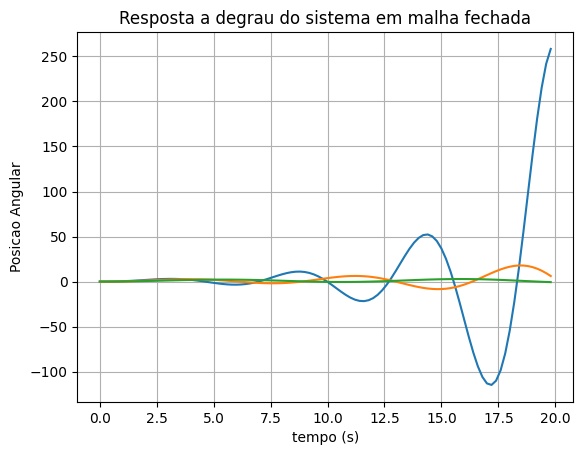]**
9. Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação $t_s$, Máximo sobresinal $M_p$ da variável $\omega_o(t)$ e $\max v_p(t)$ (Valor máximo da saída do controlador $v_p(t)$)
 
|$$T_i$$|$$t_r$$|$$t_s$$|$$M_p$$|$$\max v_p(t)$$|
|:-|:-|:-|:-|:-|
|$$T_{i_1}$$|0.92|6.25|32%|1.32|
|$$T_{i_2}$$|0.92|6.25|32%|1.32|
|$$T_{i_3}$$|0.92|6.25|32%|1.32|		  		  
 
10. Como as grandezas $t_r$, $t_s$, $M_p$ e $\max v_p(t)$ variam com a variação de $T_i$ ?

**[As grandezas não variam com o valor de Ti ]**

# 3.3 Controlador Proporcional Derivativo

O controlador PD pode ser escrito da seguinte forma:
\begin{equation}
H_1(s) = K_p(1+T_d\frac{s}{\frac{T_d}{N}s+1}),
\end{equation}

O filtro de 1a. ordem que é definido como:
\begin{equation}
\frac{1}{\frac{T_d}{N}s+1},
\end{equation}
é necessário para garantir que a parte derivativa seja um sistema causal (grau do polinômio do denominador
igual ou maior que o grau do polinômio do numerador), o que garante a estabilidade numérica da simulação.
Além disso, a componente derivativa gera valores de saída extremamente elevados para entradas rápidas, por exemplo, do tipo degrau (Para uma entrada degrau a derivada é infinita) ou ruídos de alta frequência.
Quanto menor o valor de $N$ menor a frequência de corte do filtro.

O controlador PD não possui obviamente integrador dessa forma para o sistema de controle de
velocidade apesar de que uma resposta estável e rápida possa ser obtida o erro
erro estático $\omega_{e_{ss}}$ não pode ser feito nulo.

## a. Controle de posição: controlador PD

1. Considerando que:
   $$
   H_\theta(s)=K_{tac}K_p(1+T_d\frac{s}{\frac{T_d}{N}s+1})
   $$
   e que
   \begin{equation}
   G_{\theta}(s) = \frac{K_1 K_m K_g}{s(s+a)(s+a_m)},
   \end{equation}
calcule o erro estático $\theta_{e_{ss}}$ do sistema de controle em malha fechada para uma entrada degrau $\Theta_i(s)=A/s$.

**[Resposta]**
		
2. Utilizando o script de controle de posição realize simulações do sistema de controle em malha fechada com três valores do tempo derivativo do controlador $T_d=\{ 0.05, 0.5, 5.0\}$, os outros parâmetros devem ser: $K_p = 5$, $N = 1$.		
 		
3. Escreva a função de transferência em malha aberta do sistema com valores numéricos:
$$
GH_\theta(s)=
$$ 
		
4. Identifique os pólos de malha aberta $GH_\theta(s)$ para cada um dos valores de $T_d$:
 
|$$K$$|$$T_{d_1}$$|$$T_{d_2}$$|$$T_{d_3}$$|
|:-|:-|:-|:-|
|pólo 1|x|x|x|
|pólo 2|x|x|x|  
|pólo 3|x|x|x|   
|pólo 4|x|x|x|   
|zero|x|x|x|     					  		  
 
5. Escreva a função de transferência em malha fechada do sistema com valores numéricos:
 
$$
\frac{GH_\theta(s)}{1+GH_\theta(s)}=
$$		

6. Identifique os pólos da malha fechada para cada um dos valores de $K_p$:

|$$K$$|$$T_{d_1}$$|$$T_{d_2}$$|$$T_{d_3}$$|
|:-|:-|:-|:-|
|pólo 1|x|x|x|
|pólo 2|x|x|x|  
|pólo 3|x|x|x|   
|pólo 4|x|x|x|   
|zero|x|x|x|  
		
7. Compare a posição dos pólos de malha fechada em relação à posição dos pólos de malha aberta.

**[Resposta]**
 
8. Insira abaixo o gráfico da resposta transitória para uma entrada do tipo degrau unitário.

**[Faça copy and paste da imagem gerada pelo script]**
		
9. Anote na tabela abaixo os valores obtidos para o tempo de subida $t_r$, tempo de acomodação $t_s$, Máximo sobresinal $M_p$ da variável $\theta_o(t)$ e $\max v_p(t)$ (Valor máximo da saída do controlador $v_p(t)$)

|$$T_d$$|$$t_r$$|$$t_s$$|$$M_p$$|$$\max v_p(t)$$|
|:-|:-|:-|:-|:-|
|$$T_{d_1}$$|x|x|x|x|
|$$T_{d_2}$$|x|x|x|x|
|$$T_{d_3}$$|x|x|x|x|	  
	
10. Como as grandezas $t_r$, $t_s$, $M_p$ e $\max v_p(t)$ variam com a variação de $T_d$ ?
 
**[Resposta]**

# Discussões

**[Resposta]**

# Conclusões

**[Resposta]**